## Variational Inference with Gaussian Mixture Models

Antonio Esteves @ UMinho, Fev 2024

This notebook applies variational inference to a Gaussian mixture model(GMM).

### Introduction

The goal of VI is to provide computationally tractable ways to compute posterior distributions. For example in a GMM, there is a discrete (categorical latent variable $z$ taking values in $\{1,\dots,M\}$ where $M$ is the number of clusters. Given a $z$, the conditional distribution $p(x \mid z)$ is a gaussian: <P>

$x \sim p(x \mid z) = \mathbb{N}(\mu, \sigma^2)$

A probabilistic graphical model provides a model for the joint distribution $p(x,z) = p(x \mid z) p(z)$ from which we want to perform inference. Why inference? Usually, $x$ is the observed data and what we are looking for are the hidden features learned by the model, which correspond to the latent variables $z$. For example, given an observed data point, we would like to figure out which cluster it comes from. In particular, we are interested in computing: <P>

$p(z \mid x) = \frac{p(x,z)}{p(x)}$ <P>

But this is really hard to compute. For example, even with a GMM model, the marginal distribution: 

$p(x) = \sum_{i=1,\dots,M} p(z=i)\mathbb{N}(x; \mu_i, \sigma_i^2)$

is generally difficult to compute. In the cases where the prior $p(z)$ is a continuous distribution, this may be analytically impossible. What do we do instead?

### ELBO and Variational Inference

We will often opt for computing an easier lower bound for the posterior we are trying to find. This lower bound is the ELBO.

$\log p(x) \geq \mathbb{E} [\log p(x,z)] - \mathbb{E} [\log q(z)]$

Next, it is presented a picture of the resulting gaussian mixture model.

![gmm](cavi_gmm_v4_result.png)

Consider a probability distribution over observed an latet variables:

$p(x,z) = p(z)\ p(x \mid z)$

The inference problem is computing the posterior distribution

$p(z \mid x) = \frac{p(x,z)}{p(x)} = \frac{p(x,z)}{\int_z p(x,z)dz}$

The integral in the denominator $p(x) = \int_z p(x,z)dz$ is hard or impossible to compute. This term is the marginal distribution, also called the evidence.

Variational inference formulation:<P>

* First, we assume that there is a family of distributions $Q$ over $z$.
* Then, we find a distribution $q \in Q$ such that:<P>
  $q^{*} = \underset{q \in Q}{argmin} D_{KL}(q(z) \parallel p(z\mid x))$
* We approximate the posterior using $q^{*}$.

![KLmin](fig/variational_inference_2.png)

The example that we will consider in this notebook is a Gaussian mixture models (GMM). Such a model has a $K$ distributions, called components, each being a Gaussian/Normal characterized by a certain mean $\mu_k$. By assumption, each mean $\mu_k$ is sampled from a Normal: $\mu_k \sim \mathcal{N}(0,\sigma^2)$, where $\sigma^2$ is considered an hyperparameter.<P>

Thus, as a generative model a GMM is defined by:<P>
* $\mu_k \sim \mathcal{N}(0,\sigma^2)$ <P>
* $c_i \sim \text{Categorical}(1/K, 1/K,\dots,1/K) = \text{Uniform}(1,K)$<P>
* $x_i \mid c_i, \mu \sim \mathcal{N}(c_i^T\mu,1)$<P>

And it can be also represented as probabilitic graphical model:

![KLmin](fig/VI_bayesian_gmm.png)

The joint distribution is expressed by $p(z,x) \equiv p(\mu,c,x) = p(\mu) \prod_{i=1}^{N} p(c_i) p(x_i \mid c_i,\mu)$, where $\mu,c$ are the latent variables.

The evidence $p(x) will be:

$p(x) = \int p(\mu) \prod_{i=1}^{N} \sum_i p(c_i) p(x_i \mid c_i,\mu) d\mu$ <P>
$p(x) = \sum_i p(c_i) \int p(\mu) \prod_{i=1}^{N} p(x_i \mid c_i,\mu) d\mu$ <P>

So, it is difficult to compute $p(x)$ and consequently difficult to compute the posterior $p(z \mid x)$.
For this reason, we will try variational inference with the objective of finding the parameters of $q$ that minimize the $D_{KL}$:

$q^{*} = \underset{q \in Q}{argmin} D_{KL}(q(z) \parallel p(z\mid x))$

Where 

$D_{KL}(q(z) \parallel p(z\mid x)) = \mathbb{E}_{z \in q(z)}[\log q(z) - \log p(z \mid x)]$ <P>
$D_{KL}(q(z) \parallel p(z\mid x)) = \mathbb{E}_{z \in q(z)}[\log q(z)] - \mathbb{E}_{z \in q(z)}[\log p(x,z)] + \log p(x)$ <P>

We see, that $D_{KL}$ also depends on the marginal $p(x)$, that in most cases is intractable. But we know that $D_{KL}$ is always non-negative. Then, we have:

$\mathbb{E}_{z \in q(z)}[\log q(z)] - \mathbb{E}_{z \in q(z)}[\log p(x,z)] + \log p(x) \geq 0$ <P>
$\log p(x) \geq -\mathbb{E}_{z \in q(z)}[\log q(z)] + \mathbb{E}_{z \in q(z)}[\log p(x,z)]
\Leftrightarrow \log p(x) \geq ELBO$ <P>
$ELBO = \mathbb{E}_{z \in q(z)}[\log p(x,z)] - \mathbb{E}_{z \in q(z)}[\log q(z)]$ <P>

We know that evidence does not depend on $q$, therefore minimizing the $D_{KL}$ is equivalent to maximizing the ELBO. Maximizing the ELBO is tractable and we will implement it here. ELBo can be rewritten as:<P>

$ELBO = \mathbb{E}_{z \in q(z)}[\log p(x,z)] - \mathbb{E}_{z \in q(z)}[\log q(z)]$ <P>
$ELBO = \mathbb{E}_{z \in q(z)}[\log (p(x \mid z)\ p(z))] - \mathbb{E}_{z \in q(z)}[\log q(z)]$ <P>
$ELBO = \mathbb{E}_{z \in q(z)}[\log p(x \mid z) + \log p(z)] - \mathbb{E}_{z \in q(z)}[\log q(z)]$ <P>
$ELBO = \mathbb{E}_{z \in q(z)}[\log p(x \mid z)] + \mathbb{E}_{z \in q(z)}[\log p(z)] - \mathbb{E}_{z \in q(z)}[\log q(z)]$ <P>
$ELBO = \mathbb{E}_{z \in q(z)}[\log p(x \mid z)] -\{ \mathbb{E}_{z \in q(z)}[\log q(z)] - \mathbb{E}_{z \in q(z)}[\log p(z)]\}$ <P>
$ELBO = \mathbb{E}_{z \in q(z)}[\log p(x \mid z)] - D_{KL}(q(z) \parallel p(z))$ <P>

The first term in right-hand side of last equation represents the likelihood of the data. When we maximize the likelihood we are maximizing this likelihood. If we are modeling a generative movel, this terms is responsible for minimizing the reconstruction error. While the second term, is optimized to be as smal ass possible, meaning that the variational distribution $q$ approximates the true distribution $p$.

Let us direct our attention to the variational distribution $q$. To make optimization less complex, we must select a family for $q$ easier to handle. The common choice for this purpose is the mean-field assumption, where $q$ is a product of independent factors:

$q(z) = \prod_{j=1}^m q_j(z_j)$ <P>

The $q_j$ factors depend on the latent variable $z_j$. If $z_j$ is discrete, possible distributions for $q_j$ are the Categorical or Multinomial. If $z_j$ is continuous, the normal distributions is a frequent choice for $q_j$.

By using the **mean-field** assumption, the variational distribution $q$ is:

$q(\mu,c) = \prod_{k=1}^K q(\mu_k;m_k,s_k^2) \prod_{i=1}^N q(c_i; \phi_i)$

For the first term of the right-hand side of previous equation, we consider that $\mu_k \sim \mathcal{N} (m_k,s_k^2)$. In the second term of the right-hand side of previous equation, we model $\phi_i$ with a vector of size $K$, containing the probabilities of assigning $x_i$ to each of the $K$ clusters.

Therefore, the latent parameter space is $\{mk, s_k^2: k=1,\dots,K\ ;\ \phi_i \in \mathbb{R}^K, i=1,\dots,N\}$.

For the mean-field assumption, the ELBO becomes:

$
\begin{aligned}
ELBO_{q, m_k, s_k^2, \phi_i} & = \sum_{k=1}^K \mathbb{E}_{z \in q(z)}[\log p(\mu_k;m_k,s_k^2] \\
    &+ \ \sum_{i=1}^N \{ \mathbb{E}_{z \in q(z)}[\log p(c_i;\phi_i)] + \mathbb{E}_{z \in q(z)}[\log p(x_i \mid c_i,\mu;\phi_i,m,s^2)] \} \\
    &-\ \sum_{i=1}^N \mathbb{E}_{z \in q(z)}[\log q(c_i;\phi_i)]\ -\ \sum_{k=1}^K \mathbb{E}_{z \in q(z)}[\log q(\mu_k;m_k,s_k^2)]
\end{aligned}
$


To optimize the ELBO, we apply the Coordinate-Ascent (mean-fiel) Variational Inference (CAVI) method. CAVI optimizes one factor each time, while keeping the others fixed, in a iterative process. CAVI steps are:
* let $z_j$ be a latent variable.
* The complete conditional of $z_j$ is $p(z_j \mid z_{-j},x)$.
* Fix the other factors $q_{-j}$.
* Optimize $q_j(z_j)$ to maximize the ELBO, obtaining $q_j^{*}(z_j)$.  

The update rules for the parameters are:

$\phi_{i,k}^{*} \propto exp\{ -\frac{1}{2}(m_k^2+s_k^2) + x_i m_k \}$ <P>
$m_k^{*} = \dfrac{\sum_i\phi_{ik}x_i}{\tfrac{1}{\sigma^2} + \sum_i\phi_{ik}}$ <P>
$(s_k^2)^{*} = \dfrac{1}{\frac{1}{\sigma^2} + \sum_i\phi_{ik}}$ <P>

The expression of ELBO is:

$
\begin{aligned}
ELBO^{*} &= \sum_k -E_q\Big[\dfrac{m_j}{2\sigma^2}\Big] + \sum_i\sum_k E_q\Big[\phi_{ik}\Big]E_q\Big[-\dfrac{(x_i-m_k)^2}{2}\Big] \\ &- \sum_i \sum_k E_q\Big[\log~\phi_{ik}\Big] + \sum_k \dfrac{1}{2}\log~(s2_k)
\end{aligned}
$


In [1]:
import numpy   as np
import seaborn as sns
import matplotlib.pyplot as plt 

In [2]:
# Create the dataset

N        = 300
k_clusters = 3
means    = np.array([2, 5, 9])

def generate_data(N, clusters, means):
    data = []
    for c in range(clusters):
        # get N samples from Normal(means[c],1)
        cluster_data = np.random.normal(means[c], 1, N) 
        data.append(cluster_data)
    return np.concatenate(np.array(data))

data = generate_data(N, k_clusters, means)

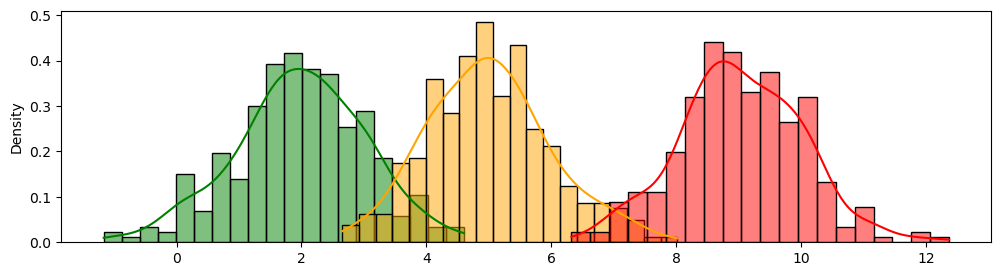

In [3]:
# plot the data

fix, ax = plt.subplots(figsize=(12,3))
sns.histplot(data[:N],    stat='density', bins=20, color='green',  kde=True) 
sns.histplot(data[N:2*N], stat='density', bins=20, color='orange', kde=True) 
sns.histplot(data[2*N:],  stat='density', bins=20, color='red',    kde=True) 
plt.show()

In [4]:
class Model:

    def __init__(self, data, num_clusters=3, sigma=1):
        self.data  = data
        self.K     = num_clusters
        self.n     = data.shape[0]
        self.sigma = sigma
        
        # get the model parameters, which CAVI will update when maximizing ELBO
        
        self.phi = np.random.dirichlet(np.random.random(self.K), self.n)
        self.m   = np.random.randint(
            low  = np.min(self.data), 
            high = np.max(self.data), 
            size = self.K
        ).astype(float)
        self.s2  = np.random.random(self.K)

    def elbo(self): # check derivation for details about ELBO calculation
        '''
        Returns the value of ELBO given the 'data', the model parameters 
        (m, s2, phi), and sigma.
        '''
        p          = -np.sum((self.m**2 + self.s2) / (2 * self.sigma**2))
        next_term  = -0.5 * np.add.outer(self.data**2, self.m**2 + self.s2)
        next_term -= np.outer(self.data, self.m)
        next_term *= self.phi
        p         += np.sum(next_term)
        q          = np.sum(np.log(self.phi)) - 0.5 * np.sum(np.log(self.s2))
        elbo       = p + q
        return elbo

    def cavi(self):
        '''
        Update the model parameters (phi, m, s2) using CAVI.
        '''
        
        # cavi 'phi' update
        
        e1       = np.outer(self.data, self.m)  # x * m
        e2       = -0.5 * (self.m**2 + self.s2) # 1/2 * (m^2 + s2)
        e        = e1 + e2[np.newaxis, :]       # x * m + 1/2 * (m^2 + s2)
        # phi* = exp(e) / (SUM exp(e)) <- expoential and normalization  
        self.phi = np.exp(e) / np.sum(np.exp(e), axis=1)[:, np.newaxis]
        
        # cavi 'm' update

        # SUM_i x_i * phi_ik
        self.m  = np.sum(self.data[:, np.newaxis] * self.phi, axis=0)
        
        #  m* = [SUM_i x_i * phi_ik] / [1/sigma^2 + SUM_i phi_ik]
        self.m /= (1.0 / self.sigma**2 + np.sum(self.phi, axis=0))
        
        # cavi 's2' update

        # s2* = 1 / [1/sigma^2 + SUM_i phi_ik]
        self.s2 = 1.0 / (1.0 / self.sigma**2 + np.sum(self.phi, axis=0))

    def train(self, epsilon=1e-5, n_iter=100):
        '''
        Optimize the ELBO with CAVI during 'n_iter' iterations and stops 
        if variation in ELBO is less than 'epsilon'.
        '''
        elbo_history = []
        elbo_history.append(self.elbo())
        
        # optimize the ELBO until it converges: delta ELBO <= epsilon
        for i in range(n_iter):
            
            self.cavi()
            elbo_new = self.elbo()
            elbo_history.append(elbo_new)
            
            if i % 5 == 0:
                print(f'ELBO: {elbo_history[i]}')
            
            # stops optimization if the last 2 values of ELBO differ less than 'epsilon'
            if np.abs(elbo_history[-1] - elbo_history[-2]) <= epsilon:
                print(f'ELBO converged after {i} iterations!')
                break
        return elbo_history


In [5]:
model       = Model(data, k_clusters)

print(f'Initial means: {model.m}')

elbo_record = model.train()

Initial means: [10.  5.  4.]
ELBO: -65011.254854680796
ELBO: -89302.87701152275
ELBO: -89416.22518006444
ELBO: -89421.6619404173
ELBO: -89421.97843555974
ELBO: -89421.99691672668
ELBO: -89421.99799601537
ELBO converged after 32 iterations!


True means:     [2, 5, 9]
Inferred means: [1.9346  4.86287 8.95754]


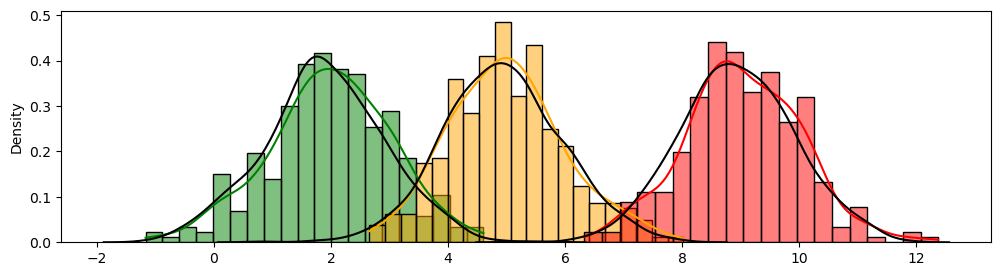

In [6]:
# plot the final parameters

assignments     = model.phi.argmax(1)
converged_means = model.m
print(f'True means:     {sorted(means)}')
print(f'Inferred means: {np.round(sorted(converged_means),5)}')

# plot the observed data

fix, ax = plt.subplots(figsize=(12,3))
sns.histplot(data[:N],    stat='density', bins=20, color='green',  kde=True) 
sns.histplot(data[N:2*N], stat='density', bins=20, color='orange', kde=True) 
sns.histplot(data[2*N:],  stat='density', bins=20, color='red',    kde=True) 

# plot the modeled gaussians

sns.kdeplot(np.random.normal(converged_means[0], 1, 1000), color='black')
sns.kdeplot(np.random.normal(converged_means[1], 1, 1000), color='black')
sns.kdeplot(np.random.normal(converged_means[2], 1, 1000), color='black')
plt.show()